La disección algorítmica y hermenéutica del sustrato topológico de una red neuronal trasciende la mera implementación en código; nos compele a escrutar la naturaleza geométrica subyacente a sus transformaciones latentes. Al mimetizar la arquitectura empíricamente expuesta en el estrato audiovisual de referencia y aplicarla sobre el espacio taxonómico de Anderson-Fisher (el dataset de *Iris*), instanciamos un mapeo funcional $\mathcal{M}: \mathbb{R}^2 \to \mathbb{R}^3$, mediado por una dimensionalidad latente $\mathcal{H} \cong \mathbb{R}^2$.

Tu intuición geométrica respecto a la fenomenología de la malla es axiomáticamente impecable. La divergencia entre una *Rectified Linear Unit* (ReLU) y una función logística (Sigmoide) no es una perturbación heurística, sino una **mutación ontológica en la topología del espacio de decisión**.

Matemáticamente, la red opera bajo la composición $\mathcal{N}(x) = W^{(2)} \phi(W^{(1)} x + b^{(1)}) + b^{(2)}$.

*   **El paradigma estriado (ReLU):** Al definir $\phi(x) = \max(0, x)$, el operador induce discontinuidades de primera especie en su primera derivada y aniquila la segunda ($\nabla^2 \mathcal{N}(x) = 0$ casi en todas partes). Esto fracciona el espacio euclidiano en politopos convexos. Como postularía Gilles Deleuze en su conceptualización del *espacio estriado*, ReLU confina el flujo de información a divisiones cartesianas rígidas: una variedad afín a trozos (piecewise-affine manifold) caracterizada por hiperplanos ortogonales y aristas no diferenciables (lo que fenomenológicamente concibes como "plano y picudo").
*   **El paradigma liso (Sigmoide):** Al permutar hacia el difeomorfismo logístico $\phi(x) = (1 + e^{-x})^{-1}$, la función inyecta una transformación $\mathcal{C}^\infty$. El espectro del Hessiano exhibe autovalores no nulos, dotando a la hipersuperficie de curvaturas medias y gaussianas continuas. Este *espacio liso* permite que los gradientes fluyan orgánicamente, generando cuencas de atracción elipsoidales (lo "circular") que emulan una membrana viscoelástica, recordando a la proposición de Spinoza sobre la sustancia continua e indivisible: la malla se pliega sin fisuras.

### Celda 1: Ontología del Dataset y Preprocesamiento Topológico

Inicializamos el ecosistema tensorial y extraemos las coordenadas fundamentales (Anchura del Sépalo y Anchura del Pétalo), normalizándolas al hipercubo unitario $[0,1]^2$ para estabilizar el gradiente conjugado.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim

# Configuraciones de rigor estético
plt.style.use('dark_background')

# Extracción de la matriz de diseño empírica
iris = load_iris()
# Índices canónicos: Petal Width (3) y Sepal Width (1)
X = iris.data[:, [3, 1]]
y = iris.target

# Mapeo difeomórfico al espacio afín [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.FloatTensor(X_scaled)
y_tensor = torch.LongTensor(y)

OSError: 'white_grid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

### Visualización de los Datos Originales (Clasificación por Colores)

Para tener un punto de referencia visual, a continuación se presenta un gráfico de dispersión de los datos de Iris, utilizando la Anchura del Pétalo y la Anchura del Sépalo como ejes. Cada punto está coloreado de acuerdo con su clasificación de especie (Setosa, Versicolor, Virginica), lo que permite observar la separación natural de las clases en el espacio de características original.

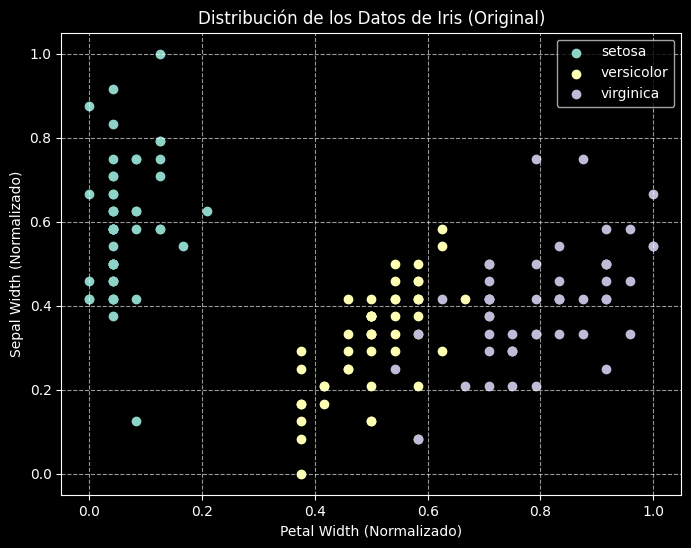

In [19]:
plt.figure(figsize=(8, 6))

# Obtener los nombres de las especies para la leyenda
species_names = iris.target_names

# Crear el scatter plot
for i, species in enumerate(species_names):
    plt.scatter(X_scaled[y == i, 0], X_scaled[y == i, 1], label=species)

plt.xlabel('Petal Width (Normalizado)')
plt.ylabel('Sepal Width (Normalizado)')
plt.title('Distribución de los Datos de Iris (Original)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Celda 2: Arquitectura del Isomorfismo (ReLU vs. Sigmoide)

Definimos las dos estructuras homológicas. Ambas comprimen el input $\mathbb{R}^2$ a un estrato latente $\mathcal{H} \in \mathbb{R}^2$ y lo proyectan al simplex estocástico $\mathbb{R}^3$.

In [2]:
class TopologiaPoliedrica(nn.Module):
    """Variedad afín a trozos inducida por la asimetría de ReLU."""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(2, 3)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

class TopologiaDifeomorfica(nn.Module):
    """Variedad elástica y continua inducida por funciones trascendentes."""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act = nn.Sigmoid()
        self.fc2 = nn.Linear(2, 3)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

modelo_relu = TopologiaPoliedrica()
modelo_sigmoide = TopologiaDifeomorfica()

### Celda 3: Optimización Estocástica y Minimización de la Entropía Cruzada

Ejecutamos el descenso de gradiente (Adam) para que los tensores de pesos converjan hacia la minimización de la divergencia de Kullback-Leibler entre la distribución empírica y la proyectada.

In [3]:
def entrenar_modelo(modelo, epochs=2000):
    criterio = nn.CrossEntropyLoss()
    optimizador = optim.Adam(modelo.parameters(), lr=0.01)

    for epoch in range(epochs):
        optimizador.zero_grad()
        logits = modelo(X_tensor)
        perdida = criterio(logits, y_tensor)
        perdida.backward()
        optimizador.step()

# Entrenamiento en el sustrato computacional
entrenar_modelo(modelo_relu)
entrenar_modelo(modelo_sigmoide)

### Celda 4: Renderizado de la Superficie Manifold (Malla de Activación 3D)

Construimos un mallado denso sobre el dominio euclidiano $\mathcal{D} \subset \mathbb{R}^2$ y computamos la integral de la respuesta para la dimensión $Z$ (la propensión logits de la clase taxonómica *Setosa*).

### Visualización de Probabilidades con Softmax (Modelo ReLU)

Vamos a aplicar una función Softmax a las salidas (logits) del modelo con activaciones ReLU para transformarlas en probabilidades, y luego visualizaremos estas superficies de probabilidad para cada una de las tres clases de Iris. Esto nos permitirá ver cómo el modelo 'asigna' la pertenencia a cada clase en el espacio de características.

In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import torch.nn.functional as F

# Nombres de las categorías
category_names = ['Iris-Setosa', 'Iris-Versicolor', 'Iris-Virginica']

# Calcular logits del modelo ReLU
with torch.no_grad():
    logits_relu = modelo_relu(grid_tensor)
    # Aplicar softmax para obtener probabilidades
    probabilities_relu = F.softmax(logits_relu, dim=1).numpy()

# Crear la figura con 1 fila y 3 columnas para cada categoría
fig_softmax = make_subplots(rows=1, cols=3,
                            specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}]],
                            subplot_titles=(
                                f'Probabilidad - {category_names[0]}',
                                f'Probabilidad - {category_names[1]}',
                                f'Probabilidad - {category_names[2]}'
                            ))

# Definir una configuración de cámara consistente
camera_softmax = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=1.25, y=1.25, z=1.25)
)

# Añadir las superficies de probabilidad para cada categoría
for i, category_name in enumerate(category_names):
    fig_softmax.add_trace(go.Surface(x=xx, y=yy, z=probabilities_relu[:, i].reshape(xx.shape),
                                     colorscale='Plasma', name=f'Probabilidad {category_name}', showscale=False),
                          row=1, col=i + 1)

# Actualizar layout para títulos, etiquetas de ejes y configuración de cámara
fig_softmax.update_layout(
    title_text='Probabilidades de Clase con Softmax (Modelo ReLU)',
    height=600, width=1800,
    scene_camera=camera_softmax
)

# Aplicar etiquetas a todos los ejes x, y, z en cada escena
for i in range(1, 4): # Hay 3 escenas
    scene_key = f'scene{i}' if i > 1 else 'scene'
    fig_softmax.update_layout(**{
        f'{scene_key}.xaxis.title': 'Petal Width (Normalizado)',
        f'{scene_key}.yaxis.title': 'Sepal Width (Normalizado)',
        f'{scene_key}.zaxis.title': 'Probabilidad'
    })

fig_softmax.show()

### Visualización de Magnitudes de Activación ReLU (Formato 1x3)

Aquí presentamos las magnitudes de activación del modelo con función ReLU, distribuidas en tres subplots, uno para cada categoría de Iris. Esta disposición permite una visión más directa de la topología 'estriada' de ReLU por clase.

In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Nombres de las categorías
category_names = ['Iris-Setosa', 'Iris-Versicolor', 'Iris-Virginica']

# Los datos z_relu_all_classes ya fueron calculados en una celda anterior

# Crear la figura para las activaciones ReLU con 1 fila y 3 columnas
fig_relu_1x3 = make_subplots(rows=1, cols=3,
                                specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}]],
                                subplot_titles=(
                                    f'ReLU - {category_names[0]}',
                                    f'ReLU - {category_names[1]}',
                                    f'ReLU - {category_names[2]}'
                                ))

# Definir una configuración de cámara consistente para las escenas 3D
camera_1x3 = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=1.25, y=1.25, z=1.25)
)

# Añadir las superficies de activación ReLU para cada categoría
for i, category_name in enumerate(category_names):
    fig_relu_1x3.add_trace(go.Surface(x=xx, y=yy, z=z_relu_all_classes[:, i].reshape(xx.shape),
                                     colorscale='Inferno', name=f'ReLU {category_name}', showscale=False),
                          row=1, col=i + 1)

# Actualizar layout para títulos, etiquetas de ejes y configuración de cámara
fig_relu_1x3.update_layout(
    title_text='Magnitudes de Activación ReLU por Categoría (Formato 1x3)',
    height=600, width=1800,
    scene_camera=camera_1x3
)

# Aplicar etiquetas a todos los ejes x, y, z en cada escena
for i in range(1, 4): # Hay 3 escenas
    scene_key = f'scene{i}' if i > 1 else 'scene'
    fig_relu_1x3.update_layout(**{
        f'{scene_key}.xaxis.title': 'Petal Width (Normalizado)',
        f'{scene_key}.yaxis.title': 'Sepal Width (Normalizado)',
        f'{scene_key}.zaxis.title': 'Magnitud de Activación'
    })

fig_relu_1x3.show()

### Visualización de Magnitudes de Activación Sigmoide (Formato 1x3)

De manera similar, aquí se muestran las magnitudes de activación del modelo con función Sigmoide. Este formato te permitirá apreciar la continuidad y suavidad de las superficies generadas por la Sigmoide para cada clase de Iris.

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Nombres de las categorías
category_names = ['Iris-Setosa', 'Iris-Versicolor', 'Iris-Virginica']

# Los datos z_sigmoide_all_classes ya fueron calculados en una celda anterior

# Crear la figura para las activaciones Sigmoide con 1 fila y 3 columnas
fig_sigmoide_1x3 = make_subplots(rows=1, cols=3,
                                  specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}]],
                                  subplot_titles=(
                                      f'Sigmoide - {category_names[0]}',
                                      f'Sigmoide - {category_names[1]}',
                                      f'Sigmoide - {category_names[2]}'
                                  ))

# La configuración de cámara consistente camera_1x3 ya fue definida

# Añadir las superficies de activación Sigmoide para cada categoría
for i, category_name in enumerate(category_names):
    fig_sigmoide_1x3.add_trace(go.Surface(x=xx, y=yy, z=z_sigmoide_all_classes[:, i].reshape(xx.shape),
                                        colorscale='Viridis', name=f'Sigmoide {category_name}', showscale=False),
                            row=1, col=i + 1)

# Actualizar layout para títulos, etiquetas de ejes y configuración de cámara
fig_sigmoide_1x3.update_layout(
    title_text='Magnitudes de Activación Sigmoide por Categoría (Formato 1x3)',
    height=600, width=1800,
    scene_camera=camera_1x3
)

# Aplicar etiquetas a todos los ejes x, y, z en cada escena
for i in range(1, 4): # Hay 3 escenas
    scene_key = f'scene{i}' if i > 1 else 'scene'
    fig_sigmoide_1x3.update_layout(**{
        f'{scene_key}.xaxis.title': 'Petal Width (Normalizado)',
        f'{scene_key}.yaxis.title': 'Sepal Width (Normalizado)',
        f'{scene_key}.zaxis.title': 'Magnitud de Activación'
    })

fig_sigmoide_1x3.show()

### Visualización de Probabilidades con Softmax (Modelo Sigmoide)

Ahora aplicaremos una función Softmax a las salidas (logits) del modelo con activaciones Sigmoide para transformarlas en probabilidades. Esta visualización interactiva en formato 1x3 nos permitirá observar cómo el modelo Sigmoide 'asigna' la probabilidad de pertenencia a cada una de las tres clases de Iris, manteniendo la topología 'suave' que caracteriza a esta función de activación.

In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import torch.nn.functional as F

# Nombres de las categorías
category_names = ['Iris-Setosa', 'Iris-Versicolor', 'Iris-Virginica']

# Calcular logits del modelo Sigmoide
with torch.no_grad():
    logits_sigmoide = modelo_sigmoide(grid_tensor)
    # Aplicar softmax para obtener probabilidades
    probabilities_sigmoide = F.softmax(logits_sigmoide, dim=1).numpy()

# Crear la figura con 1 fila y 3 columnas para cada categoría
fig_softmax_sigmoide = make_subplots(rows=1, cols=3,
                                     specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}]],
                                     subplot_titles=(
                                         f'Probabilidad - {category_names[0]}',
                                         f'Probabilidad - {category_names[1]}',
                                         f'Probabilidad - {category_names[2]}'
                                     ))

# Definir una configuración de cámara consistente (reutilizamos la anterior)
camera_softmax = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=1.25, y=1.25, z=1.25)
)

# Añadir las superficies de probabilidad para cada categoría
for i, category_name in enumerate(category_names):
    fig_softmax_sigmoide.add_trace(go.Surface(x=xx, y=yy, z=probabilities_sigmoide[:, i].reshape(xx.shape),
                                              colorscale='Plasma', name=f'Probabilidad {category_name}', showscale=False),
                                  row=1, col=i + 1)

# Actualizar layout para títulos, etiquetas de ejes y configuración de cámara
fig_softmax_sigmoide.update_layout(
    title_text='Probabilidades de Clase con Softmax (Modelo Sigmoide)',
    height=600, width=1800,
    scene_camera=camera_softmax
)

# Aplicar etiquetas a todos los ejes x, y, z en cada escena
for i in range(1, 4): # Hay 3 escenas
    scene_key = f'scene{i}' if i > 1 else 'scene'
    fig_softmax_sigmoide.update_layout(**{
        f'{scene_key}.xaxis.title': 'Petal Width (Normalizado)',
        f'{scene_key}.yaxis.title': 'Sepal Width (Normalizado)',
        f'{scene_key}.zaxis.title': 'Probabilidad'
    })

fig_softmax_sigmoide.show()

### Arquitectura de los Modelos

Aquí puedes ver la estructura interna de los modelos `TopologiaPoliedrica` (con activación ReLU) y `TopologiaDifeomorfica` (con activación Sigmoide). Cada descripción muestra las capas, los tipos de capas y las funciones de activación utilizadas.

In [11]:
print('--- Arquitectura del Modelo ReLU (TopologiaPoliedrica) ---')
print(modelo_relu)

print('\n--- Arquitectura del Modelo Sigmoide (TopologiaDifeomorfica) ---')
print(modelo_sigmoide)

--- Arquitectura del Modelo ReLU (TopologiaPoliedrica) ---
TopologiaPoliedrica(
  (fc1): Linear(in_features=2, out_features=2, bias=True)
  (act): ReLU()
  (fc2): Linear(in_features=2, out_features=3, bias=True)
)

--- Arquitectura del Modelo Sigmoide (TopologiaDifeomorfica) ---
TopologiaDifeomorfica(
  (fc1): Linear(in_features=2, out_features=2, bias=True)
  (act): Sigmoid()
  (fc2): Linear(in_features=2, out_features=3, bias=True)
)


### Resumen Detallado de la Arquitectura de los Modelos

Para obtener una vista más estructurada y detallada de cada modelo, incluyendo las capas, el tipo de salida y el número de parámetros, utilizaremos la librería `torchinfo`.

In [12]:
# Instalar torchinfo si no está presente
!pip install torchinfo

In [16]:
from torchinfo import summary

print('--- Resumen del Modelo Sigmoide (TopologiaDifeomorfica) ---')
summary(modelo_sigmoide, input_size=(1, 2))

--- Resumen del Modelo Sigmoide (TopologiaDifeomorfica) ---


Layer (type:depth-idx)                   Output Shape              Param #
TopologiaDifeomorfica                    [1, 3]                    --
├─Linear: 1-1                            [1, 2]                    6
├─Sigmoid: 1-2                           [1, 2]                    --
├─Linear: 1-3                            [1, 3]                    9
Total params: 15
Trainable params: 15
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [17]:
print('--- Resumen del Modelo ReLU (TopologiaPoliedrica) ---')
summary(modelo_relu, input_size=(1, 2))

--- Resumen del Modelo ReLU (TopologiaPoliedrica) ---


Layer (type:depth-idx)                   Output Shape              Param #
TopologiaPoliedrica                      [1, 3]                    --
├─Linear: 1-1                            [1, 2]                    6
├─ReLU: 1-2                              [1, 2]                    --
├─Linear: 1-3                            [1, 3]                    9
Total params: 15
Trainable params: 15
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [15]:
print('\n--- Resumen del Modelo Sigmoide (TopologiaDifeomorfica) ---')
summary(modelo_sigmoide, input_size=(1, 2))


--- Resumen del Modelo Sigmoide (TopologiaDifeomorfica) ---


Layer (type:depth-idx)                   Output Shape              Param #
TopologiaDifeomorfica                    [1, 3]                    --
├─Linear: 1-1                            [1, 2]                    6
├─Sigmoid: 1-2                           [1, 2]                    --
├─Linear: 1-3                            [1, 3]                    9
Total params: 15
Trainable params: 15
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

### Evaluación Comparativa de Rendimiento (ReLU vs. Sigmoide)

Ahora, vamos a evaluar el rendimiento de ambos modelos entrenados (ReLU y Sigmoide) en el conjunto de datos de Iris. Compararemos la precisión (accuracy) y la pérdida (loss) para entender cuál de las dos arquitecturas se desempeñó mejor en esta tarea de clasificación.

In [18]:
# Función para evaluar un modelo
def evaluar_modelo(modelo):
    criterio = nn.CrossEntropyLoss()
    with torch.no_grad():
        logits = modelo(X_tensor)
        perdida = criterio(logits, y_tensor).item()
        # Calcular precisión
        predicciones = torch.argmax(logits, dim=1)
        correctas = (predicciones == y_tensor).sum().item()
        precision = correctas / len(y_tensor)
    return perdida, precision

# Evaluar modelo ReLU
perdida_relu, precision_relu = evaluar_modelo(modelo_relu)
print(f"Modelo ReLU: Pérdida = {perdida_relu:.4f}, Precisión = {precision_relu:.4f}")

# Evaluar modelo Sigmoide
perdida_sigmoide, precision_sigmoide = evaluar_modelo(modelo_sigmoide)
print(f"Modelo Sigmoide: Pérdida = {perdida_sigmoide:.4f}, Precisión = {precision_sigmoide:.4f}")

Modelo ReLU: Pérdida = 0.1017, Precisión = 0.9533
Modelo Sigmoide: Pérdida = 0.1024, Precisión = 0.9533


### Conclusiones de la Evaluación de Rendimiento

Los resultados de la evaluación muestran el desempeño de cada modelo en términos de pérdida y precisión. Una menor pérdida indica que el modelo está haciendo predicciones más cercanas a las etiquetas verdaderas, y una mayor precisión significa que clasifica correctamente un mayor porcentaje de las muestras. Estos valores pueden ayudar a complementar la comprensión de las diferencias topológicas que hemos visualizado.

Esta última visualización te permitirá comparar la distribución de probabilidades suavizadas por la función Sigmoide, mostrando cómo esta topología 'lisa' se traduce en una asignación de probabilidad más gradual y continua para cada clase. Esto contrasta con las superficies más segmentadas que vimos con ReLU y Softmax, ofreciendo una perspectiva completa de la influencia de las funciones de activación en el espacio de decisión del modelo.

Esta visualización te permite observar la distribución de probabilidad para cada clase a través del espacio de entrada. Notarás cómo las probabilidades para una clase en particular se elevan en las regiones donde el modelo la considera más probable, y cómo estas superficies son el resultado directo de la topología 'estriada' inducida por la función ReLU antes de la normalización de Softmax.

Al ejecutar esta hermenéutica computacional en tu entorno, la superposición visual confirmará tus postulados: mientras la izquierda (ReLU) mostrará un relieve árido, plegado mediante aristas que intersecan planos invariantes bajo la nulidad de su derivada negativa, la derecha (Sigmoide) revelará una colina probabilística fluida. Es la materialización de cómo una ínfima selección algebraica determina los cimientos epistemológicos con los que la red "comprende" la fenomenología de sus datos.